In [73]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

In [74]:
name = "TOI-1181"
mission = "TESS"
author = "SPOC"

In [35]:
tpf = lk.search_tesscut(name)
print(tpf)

SearchResult containing 43 data products.

 #     mission     year  author exptime target_name distance
                                   s                 arcsec 
--- -------------- ---- ------- ------- ----------- --------
  0 TESS Sector 16 2019 TESScut    1426    TOI-1181      0.0
  1 TESS Sector 15 2019 TESScut    1426    TOI-1181      0.0
  2 TESS Sector 17 2019 TESScut    1426    TOI-1181      0.0
  3 TESS Sector 14 2019 TESScut    1426    TOI-1181      0.0
  4 TESS Sector 18 2019 TESScut    1426    TOI-1181      0.0
  5 TESS Sector 19 2019 TESScut    1426    TOI-1181      0.0
  6 TESS Sector 20 2019 TESScut    1426    TOI-1181      0.0
  7 TESS Sector 26 2020 TESScut    1426    TOI-1181      0.0
  8 TESS Sector 25 2020 TESScut    1426    TOI-1181      0.0
  9 TESS Sector 24 2020 TESScut    1426    TOI-1181      0.0
 10 TESS Sector 23 2020 TESScut    1426    TOI-1181      0.0
 11 TESS Sector 21 2020 TESScut    1426    TOI-1181      0.0
 12 TESS Sector 22 2020 TESScut    1426   

In [75]:
tpf = lk.search_targetpixelfile(name, mission=mission, author=author)
print(tpf)

SearchResult containing 42 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 24 2020   SPOC     120   229510866      0.0
  1 TESS Sector 25 2020   SPOC     120   229510866      0.0
  2 TESS Sector 26 2020   SPOC     120   229510866      0.0
  3 TESS Sector 40 2021   SPOC     120   229510866      0.0
  4 TESS Sector 41 2021   SPOC     120   229510866      0.0
  5 TESS Sector 47 2021   SPOC     120   229510866      0.0
  6 TESS Sector 59 2022   SPOC     120   229510866      0.0
  7 TESS Sector 58 2022   SPOC     120   229510866      0.0
  8 TESS Sector 57 2022   SPOC     120   229510866      0.0
  9 TESS Sector 56 2022   SPOC     120   229510866      0.0
 10 TESS Sector 55 2022   SPOC     120   229510866      0.0
 11 TESS Sector 54 2022   SPOC     120   229510866      0.0
 12 TESS Sector 51 2022   SPOC     120   229510866      0

In [78]:
downloaded = tpf[2].download()

<Axes: title={'center': 'Target ID: 229510866, Cadence: 563625'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

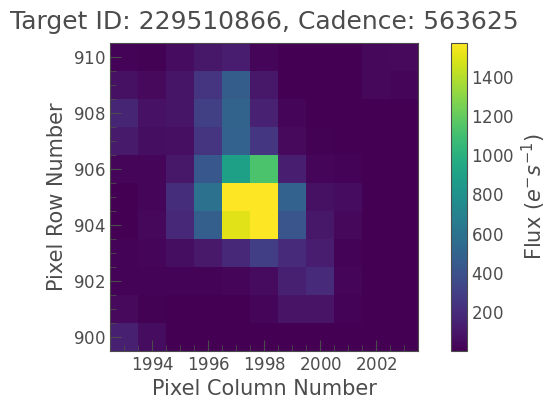

In [79]:
downloaded.plot()

In [60]:
def plot_lc(tpf, size = (11,11), apply_regressor_bool = False):
    downloaded = tpf[1].download(cutout_size = size)
    if apply_regressor_bool:
        uncorr, corr = apply_regressor(downloaded)
    else:
        aper = downloaded.create_threshold_mask()
        corr = downloaded.to_lightcurve(aperture_mask=aper).remove_outliers()

    return corr, downloaded, aper

In [98]:
def apply_regressor(tpf, aperture_mask = None):
    """
    """
    from lightkurve.correctors import DesignMatrix, RegressionCorrector
    if aperture_mask is None:
        aper = tpf.create_threshold_mask()
    else:
        aper = aperture_mask

    uncorrected_lc = tpf.to_lightcurve(aperture_mask=aper).remove_nans().remove_outliers()
    # Make a design matrix and pass it to a linear regression corrector
    dm = DesignMatrix(tpf.flux[:, ~aper].remove_outliers(), name='regressors').pca(5).append_constant()
    rc = RegressionCorrector(uncorrected_lc)
    corrected_ffi_lc = rc.correct(dm)

    # Optional: Remove the scattered light, allowing for the large offset from scattered light
    corrected_ffi_lc = uncorrected_lc - rc.model_lc + np.percentile(rc.model_lc.flux, 5)

    return uncorrected_lc.normalize(), corrected_ffi_lc.normalize()

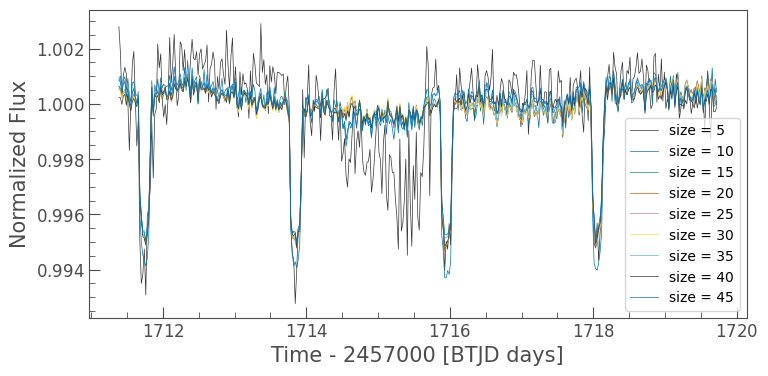

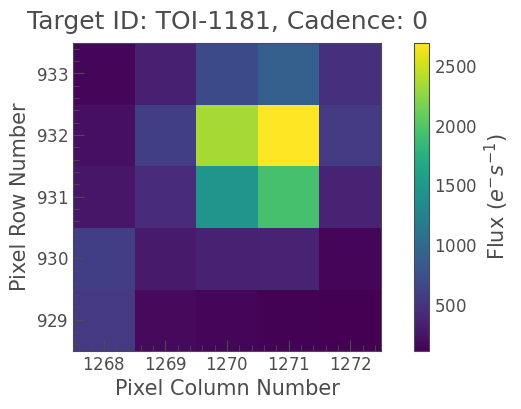

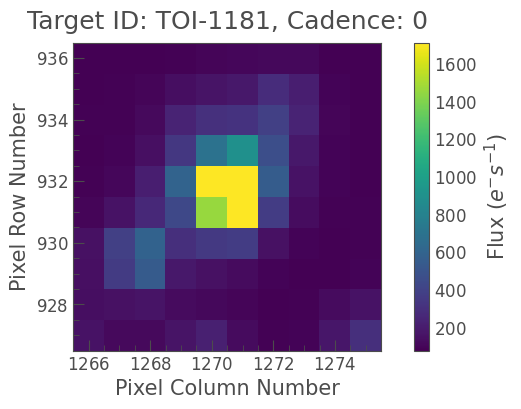

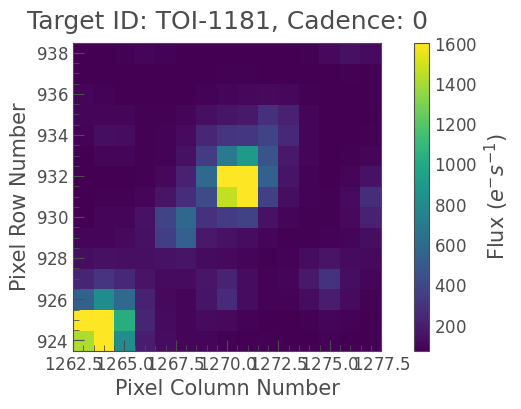

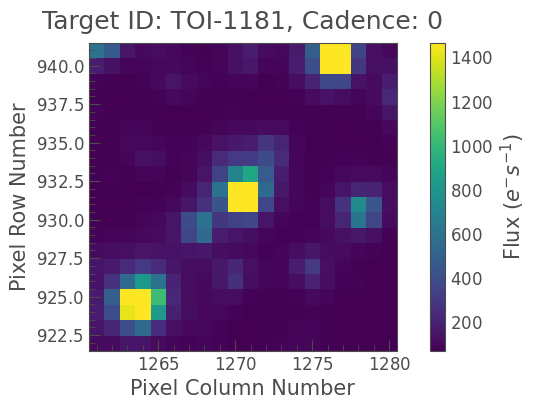

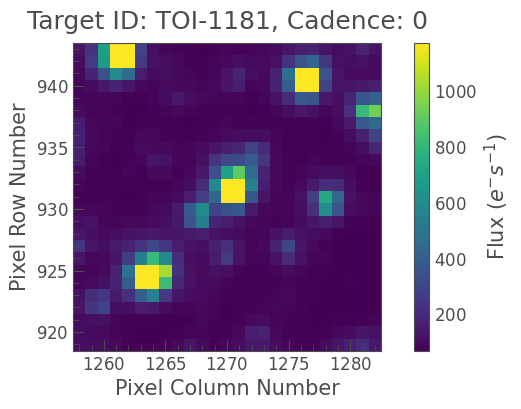

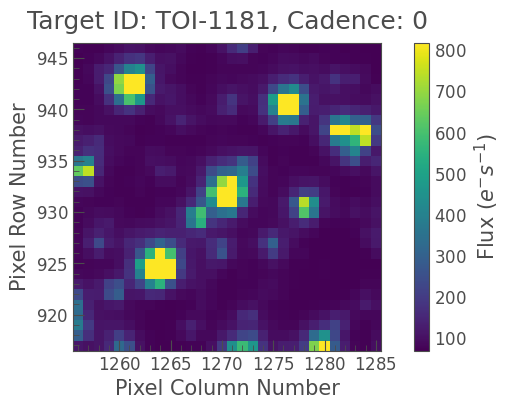

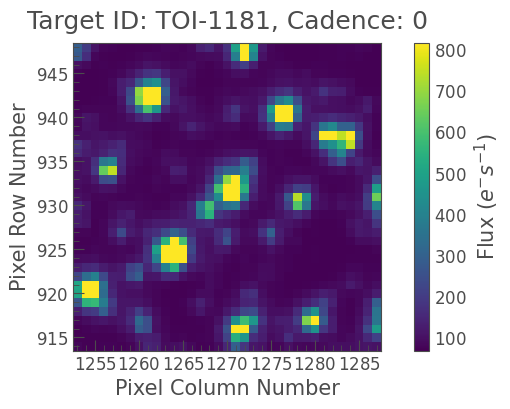

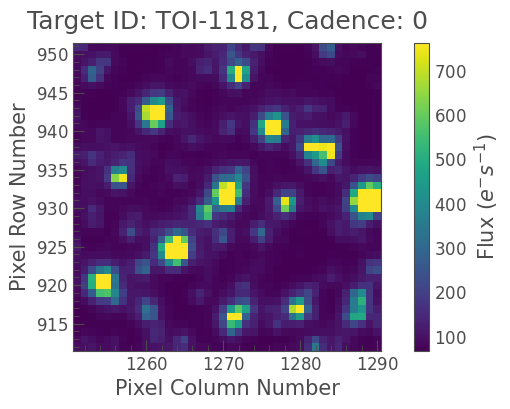

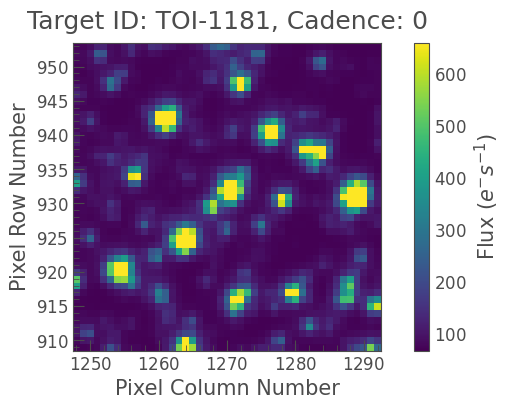

In [65]:
downloaded = []
aper_list = []
lc, down = plot_lc(tpf, size= (5,5), apply_regressor_bool=True)
downloaded.append(down)
ax = lc[:400].plot(label = "size = 5")
for i in range(10,50,5):
    lc, down = plot_lc(tpf, size = (i,i), apply_regressor_bool=True)
    lc[:400].plot(label = f"size = {i}", ax=ax)
    downloaded.append(down)

plt.legend()
plt.show()

for i in downloaded:
    i.plot()
    plt.show()


In [44]:
test_lc = downloaded[0].to_lightcurve(aperture_mask = downloaded[0].create_threshold_mask())

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

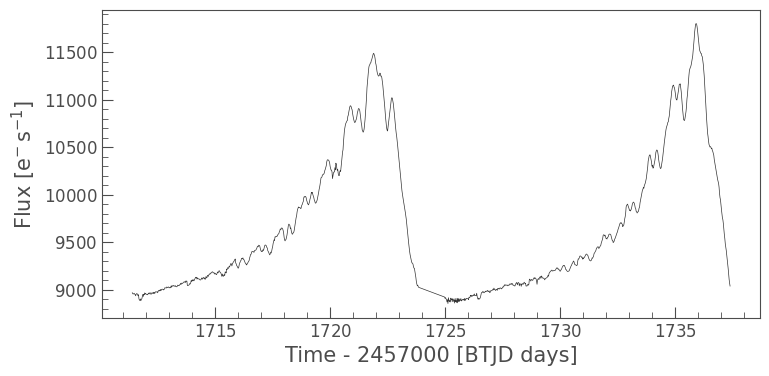

In [45]:
test_lc.plot()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

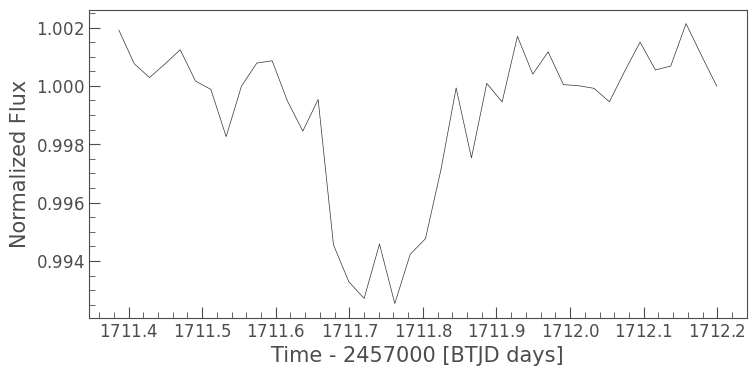

In [53]:
test_lc[0:40].normalize().plot()

In [ ]:
plot_lc

In [100]:
def apply_regressor(tpf, aperture_mask=None):
    """
    Apply a regression corrector to the light curve extracted from a TPF.
    """
    import numpy as np
    from lightkurve.correctors import DesignMatrix, RegressionCorrector

    # Choose or generate an aperture mask
    if aperture_mask is None:
        aper = tpf.create_threshold_mask()
    else:
        aper = aperture_mask

    # Extract the raw light curve and clean it
    lc_raw = tpf.to_lightcurve(aperture_mask=aper)
    uncorrected_lc = lc_raw.remove_nans().remove_outliers()

    # Create a time mask: find which TPF timestamps are present in the cleaned light curve
    time_mask = np.in1d(tpf.time.value, uncorrected_lc.time.value)

    # Apply the time mask to tpf.flux to get the corresponding flux values
    clean_flux = tpf.flux[time_mask, :, :]

    # Build the design matrix using the pixels outside the aperture
    dm = DesignMatrix(clean_flux[:, ~aper], name='regressors').pca(5).append_constant()

    # Initialize the regression corrector and correct the light curve
    rc = RegressionCorrector(uncorrected_lc)
    corrected_ffi_lc = rc.correct(dm)

    # Optional: Remove scattered light with an offset correction
    corrected_ffi_lc = uncorrected_lc - rc.model_lc + np.percentile(rc.model_lc.flux, 5)

    # Return normalized light curves
    return uncorrected_lc.normalize(), corrected_ffi_lc.normalize()


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

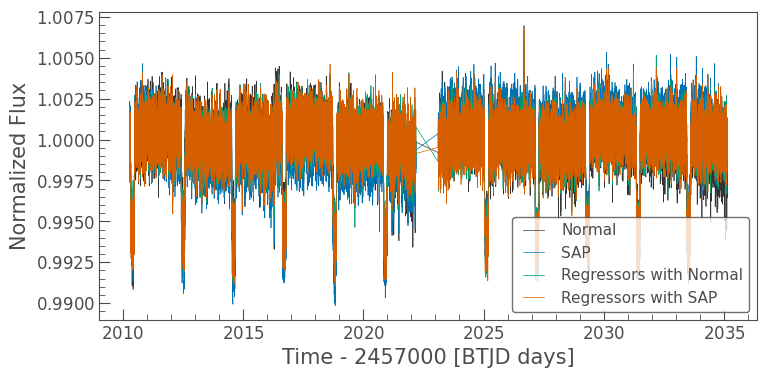

In [102]:
aper_normal = downloaded.create_threshold_mask()
aper_SAP = downloaded.pipeline_mask

lc_normal = downloaded.to_lightcurve(aperture_mask = aper_normal).remove_outliers().normalize()

lc_SAP = downloaded.to_lightcurve(aperture_mask = aper_SAP).remove_outliers().normalize()

ax = lc_normal.plot(label = "Normal")
lc_SAP.plot(label = "SAP", ax=ax)
# plt.show()

_, lc_regressor_with_normal = apply_regressor(downloaded)
_, lc_regressor_with_SAP, = apply_regressor(downloaded, aperture_mask=aper_SAP)

lc_regressor_with_normal.plot(ax = ax, label = "Regressors with Normal")
lc_regressor_with_SAP.plot(ax = ax, label = "Regressors with SAP")


/opt/anaconda3/envs/MastersProj/lib/python3.12/site-packages/astropy/utils/decorators.py:617: LightkurveDeprecationWarning: "t0" was deprecated in version 2.0 and will be removed in a future version. Use argument "epoch_time" instead.
  return function(*args, **kwargs)


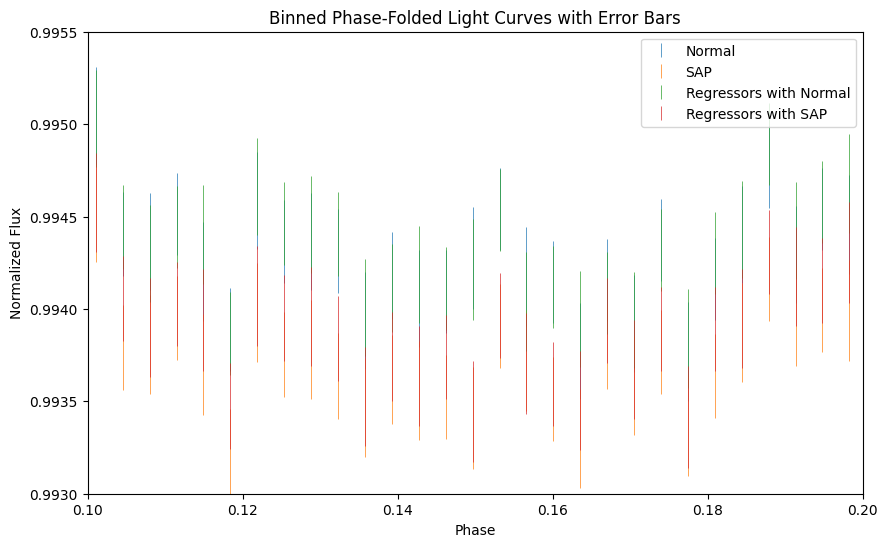

In [118]:
import astropy.units as u
import matplotlib.pyplot as plt

# Define the period (in days) and t0 (reference epoch)
period = 2.1  # example period in days
t0 = lc_normal.time[0]  # using the first timestamp as an example t0

# Phase-fold each light curve using the same period and t0.
phase_lc_normal        = lc_normal.fold(period=period, t0=t0)
phase_lc_SAP           = lc_SAP.fold(period=period, t0=t0)
phase_regressor_normal = lc_regressor_with_normal.fold(period=period, t0=t0)
phase_regressor_SAP    = lc_regressor_with_SAP.fold(period=period, t0=t0)

# Bin the phase-folded light curves using a time bin size of 5 minutes.
binned_phase_lc_normal        = phase_lc_normal.bin(time_bin_size=5*u.minute)
binned_phase_lc_SAP           = phase_lc_SAP.bin(time_bin_size=5*u.minute)
binned_phase_regressor_normal = phase_regressor_normal.bin(time_bin_size=5*u.minute)
binned_phase_regressor_SAP    = phase_regressor_SAP.bin(time_bin_size=5*u.minute)

# Plot the binned (phase-folded) light curves with error bars.
fig, ax = plt.subplots(figsize=(10, 6))

# Each binned light curve is plotted with its error bars using the built-in errorbar method.
binned_phase_lc_normal.errorbar(ax=ax, label="Normal")
binned_phase_lc_SAP.errorbar(ax=ax, label="SAP")
binned_phase_regressor_normal.errorbar(ax=ax, label="Regressors with Normal")
binned_phase_regressor_SAP.errorbar(ax=ax, label="Regressors with SAP")

ax.set_title("Binned Phase-Folded Light Curves with Error Bars")
ax.set_xlabel("Phase")
ax.set_ylabel("Normalized Flux")
ax.set_xlim(0.1, 0.2)
ax.set_ylim(0.993, 0.9955)
ax.legend()

plt.show()

